# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import platform
import mlflow

print(platform.python_version())
print(mlflow.__version__)

3.12.7
2.19.0


In [2]:
import os, shutil
import zipfile
import random
from random import sample
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq


%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder


# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from kaggle.api.kaggle_api_extended import KaggleApi


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
load_dotenv()

api = KaggleApi()
api.authenticate()

# BASE_PATH= '/Users/macbook-airm2/Documents/Eksperimen_SML_Putu'

PATH = Path("dataset")

# membuat folder dataset jika belum ada
PATH.mkdir(parents=True, exist_ok=True)


datasets = {
    'taweilo/loan-approval-classification-data': PATH
}

for dataset, path in datasets.items():
    os.makedirs(path, exist_ok=True)
    api.dataset_download_files(dataset, path=path, unzip=True)
    print("Path to dataset files:", path)

Dataset URL: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data
Path to dataset files: dataset


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# load data

base_dir = Path(PATH)


df = pd.read_csv(os.path.join(base_dir, 'loan_data.csv'))

print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Shape dataset : {df.shape}")

df.head(10)

Jumlah baris  : 45,000
Jumlah kolom  : 14
Shape dataset : (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [5]:
# Menampilkan info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
# Menampilkan deskripsi data
df.describe().round(0)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.0,45000.0,45000.0,45000.0,45000.0,45000.0,45000.0,45000.0,45000.0
mean,28.0,80319.0,5.0,9583.0,11.0,0.0,6.0,633.0,0.0
std,6.0,80422.0,6.0,6315.0,3.0,0.0,4.0,50.0,0.0
min,20.0,8000.0,0.0,500.0,5.0,0.0,2.0,390.0,0.0
25%,24.0,47204.0,1.0,5000.0,9.0,0.0,3.0,601.0,0.0
50%,26.0,67048.0,4.0,8000.0,11.0,0.0,4.0,640.0,0.0
75%,30.0,95789.0,8.0,12237.0,13.0,0.0,8.0,670.0,0.0
max,144.0,7200766.0,125.0,35000.0,20.0,1.0,30.0,850.0,1.0


In [7]:
# cek missing value 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df)
print(f"\n✅ Total kolom dengan missing value: {(missing > 0).sum()}")

                                Missing Count  Missing (%)
person_age                                  0          0.0
person_gender                               0          0.0
person_education                            0          0.0
person_income                               0          0.0
person_emp_exp                              0          0.0
person_home_ownership                       0          0.0
loan_amnt                                   0          0.0
loan_intent                                 0          0.0
loan_int_rate                               0          0.0
loan_percent_income                         0          0.0
cb_person_cred_hist_length                  0          0.0
credit_score                                0          0.0
previous_loan_defaults_on_file              0          0.0
loan_status                                 0          0.0

✅ Total kolom dengan missing value: 0


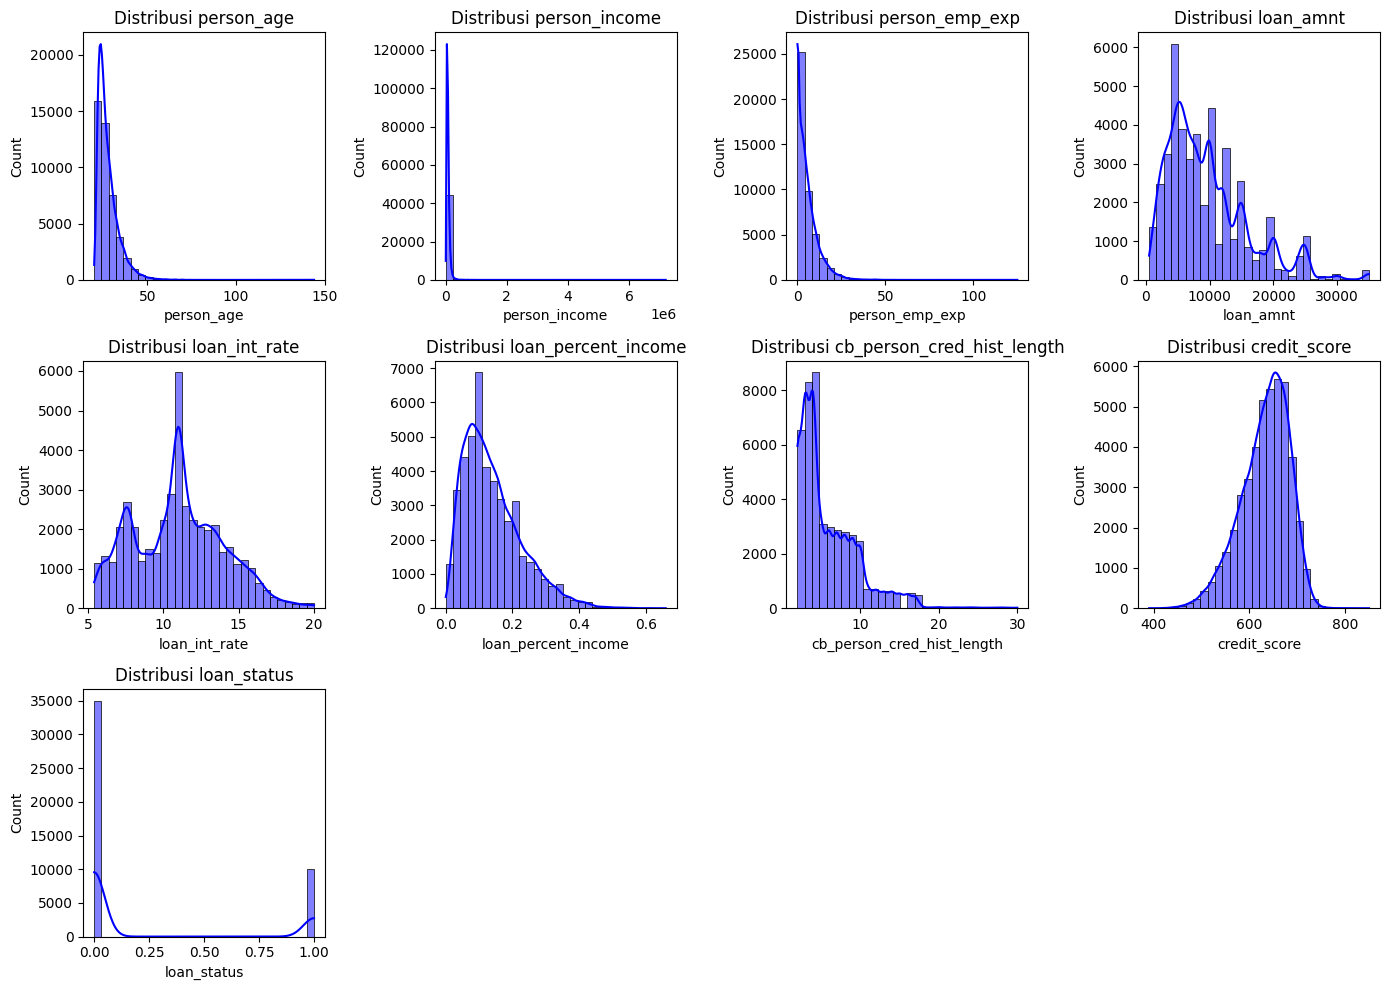

In [8]:
# Distribusi fitur numerik
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

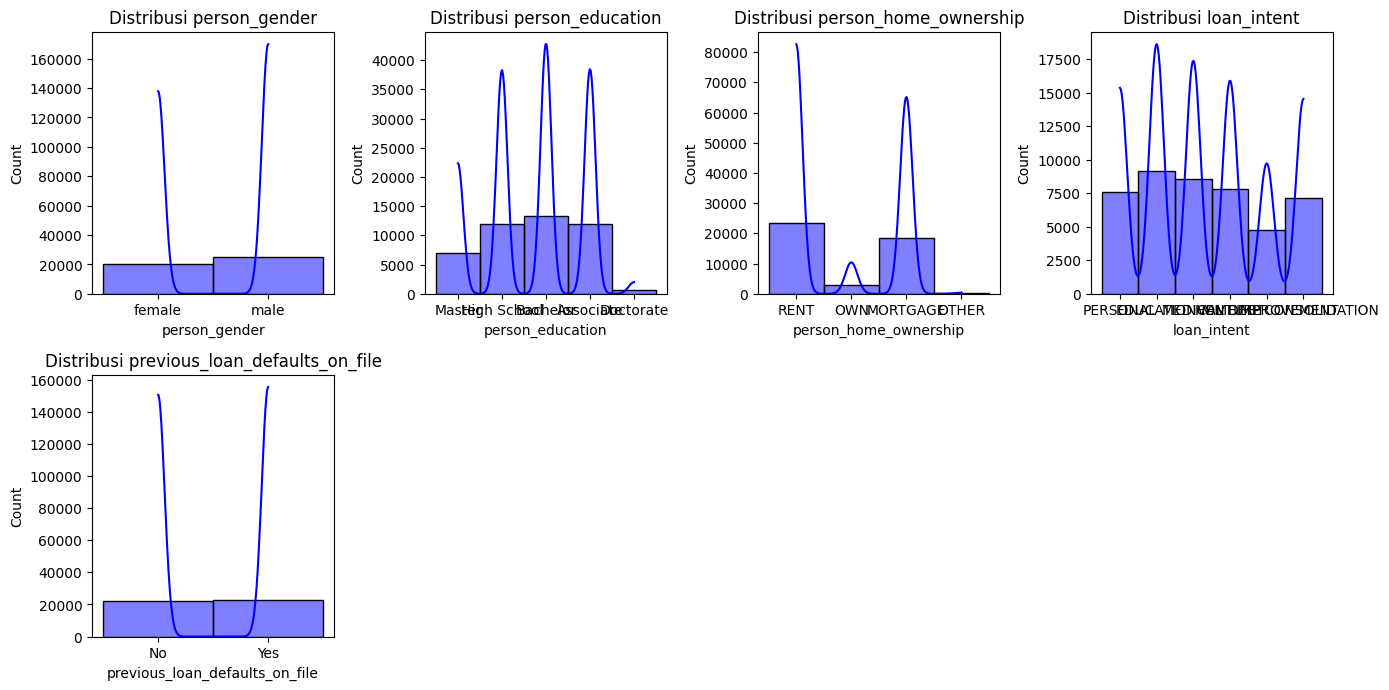

In [9]:
# Distribusi fitur numerik
cat_features = df.select_dtypes(include=['object'])
plt.figure(figsize=(14, 10))
for i, column in enumerate(cat_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

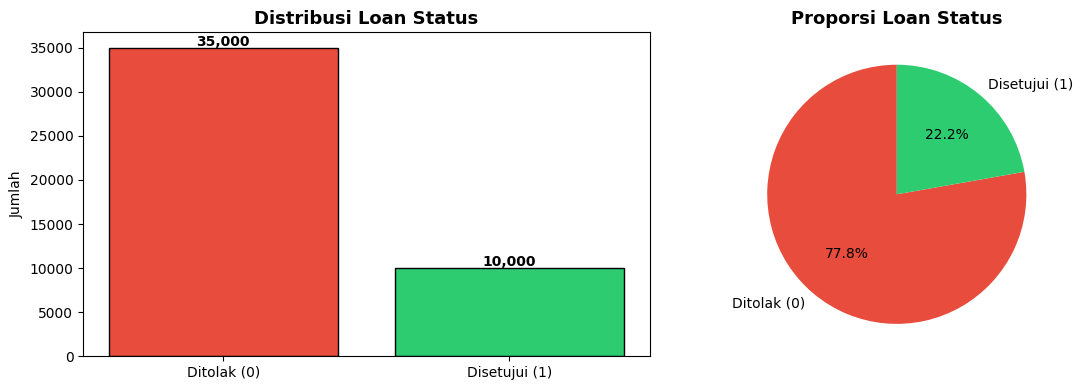

   Ditolak (0)   : 35,000 (77.8%)
   Disetujui (1) : 10,000 (22.2%)


In [10]:
# distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
counts = df['loan_status'].value_counts()
labels = ['Ditolak (0)', 'Disetujui (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Loan Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Loan Status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


print(f"   Ditolak (0)   : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"   Disetujui (1) : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")

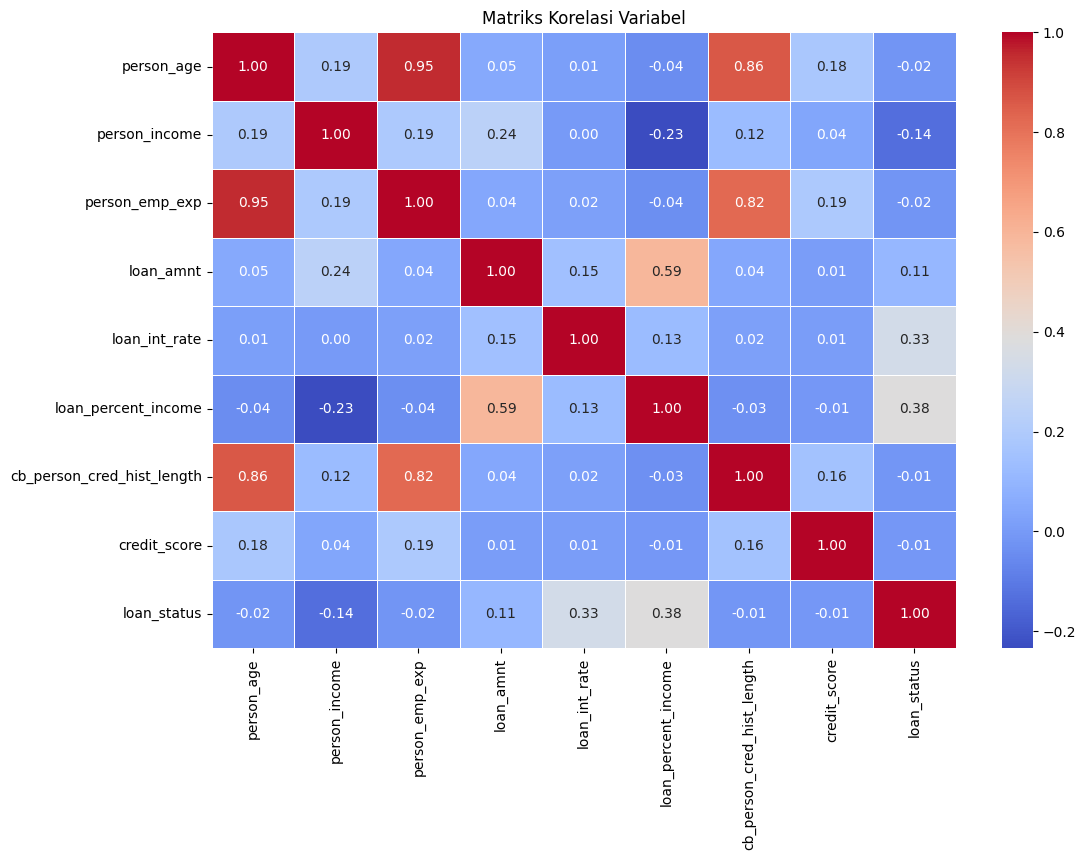

In [11]:
# matrik correlation

correlation_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriks Korelasi Variabel')
plt.show()

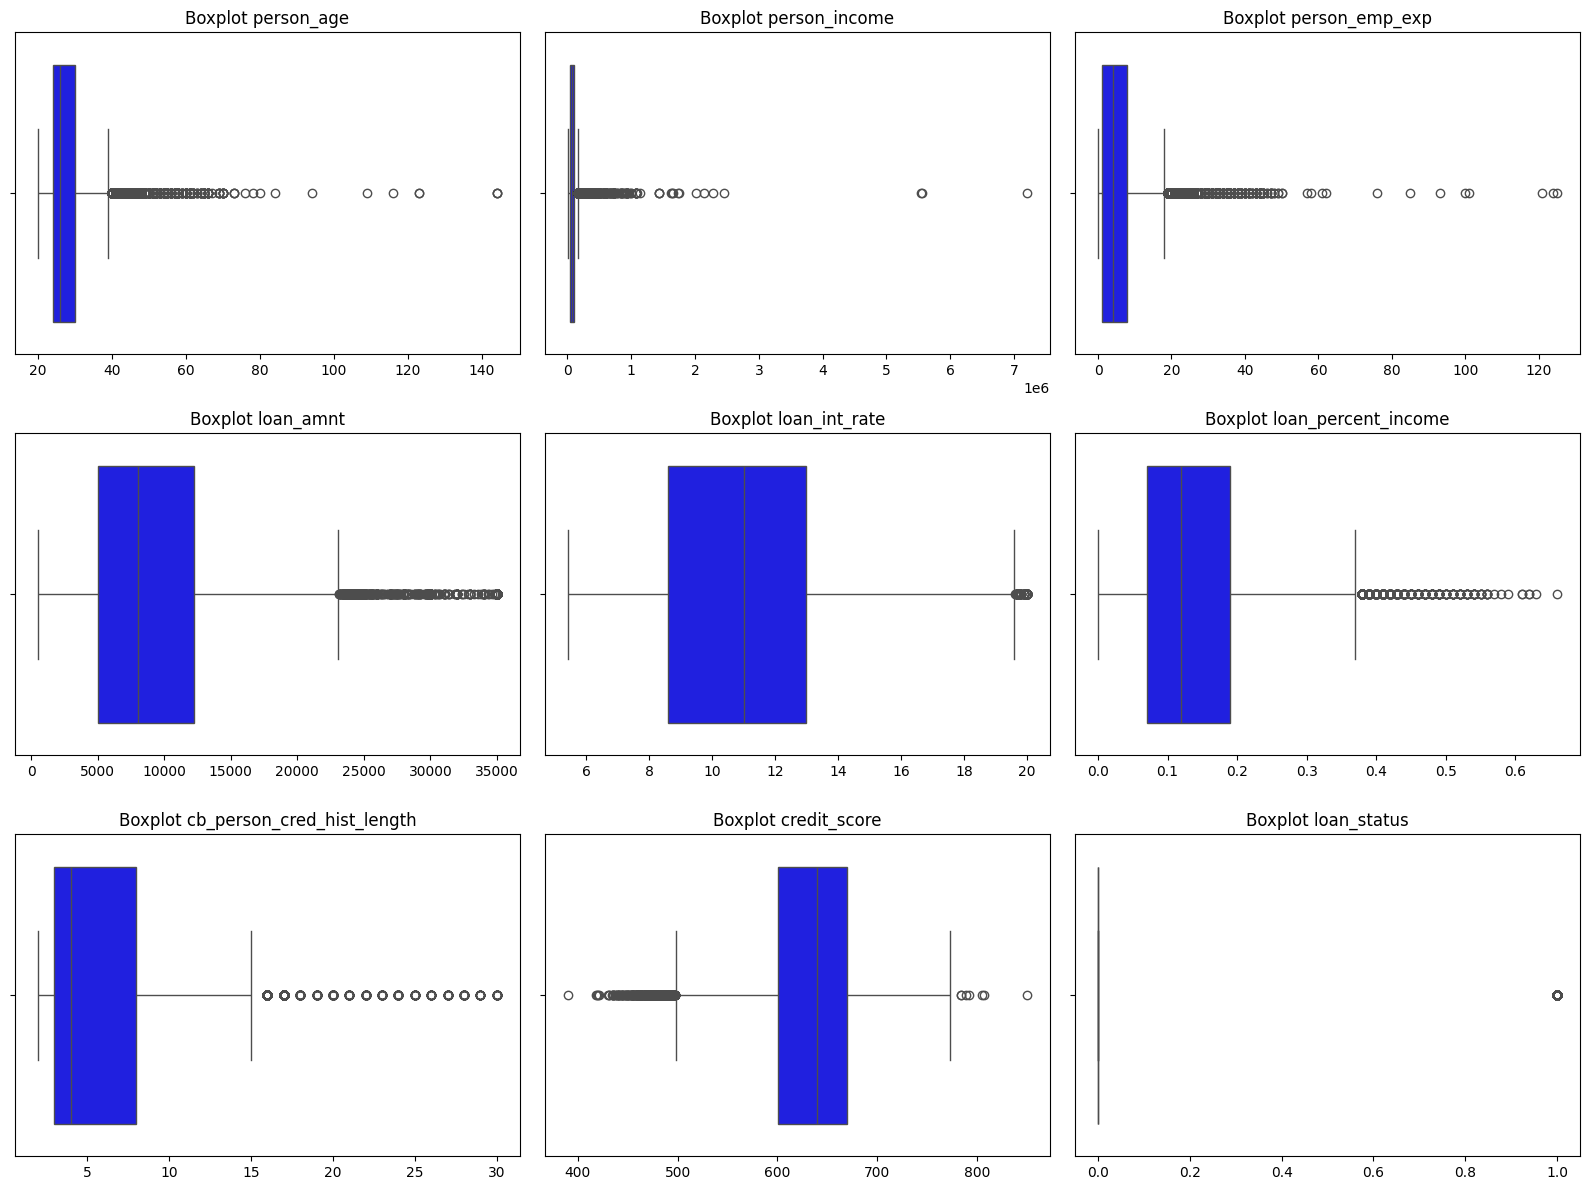

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mengambil fitur numerik saja
num_features = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))

# Perulangan untuk membuat boxplot tiap kolom
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 3, i) # Menyesuaikan grid (3 baris x 3 kolom = 9 fitur)
    
    # Menggunakan boxplot dari Seaborn
    sns.boxplot(x=df[column], color='blue') 
    
    plt.title(f'Boxplot {column}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# handle null & duplicate value 

df.dropna(inplace=True)
df.isnull().sum()


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [14]:
# handle outlier dengan metode statistik
df_pre = df.copy()

# Memilih hanya kolom numerik (target 'loan_status' tidak perlu di-clip)
num_features = df.select_dtypes(include=[np.number]).columns.drop('loan_status')

for col in num_features:
    # 1. Hitung Q1, Q3, dan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Hitung batas bawah dan batas atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Lakukan Clipping menggunakan fungsi bawaan pandas .clip()
    df_pre[col] = df_pre[col].clip(lower=lower_bound, upper=upper_bound)

# Mengecek hasil
print(df_pre.describe())

         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   45000.000000    45000.000000  45000.000000   
mean      27.444733   75677.400428        5.170311   9411.042900   
std        4.930055   38071.779506        5.137068   5832.950765   
min       20.000000    8000.000000        0.000000    500.000000   
25%       24.000000   47204.000000        1.000000   5000.000000   
50%       26.000000   67048.000000        4.000000   8000.000000   
75%       30.000000   95789.250000        8.000000  12237.250000   
max       39.000000  168667.125000       18.500000  23093.125000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   45000.000000         45000.000000                45000.000000   
mean       11.005676             0.138842                    5.783711   
std         2.976069             0.084360                    3.578787   
min         5.420000             0.000000                    2.000000   
25%         8.590000  

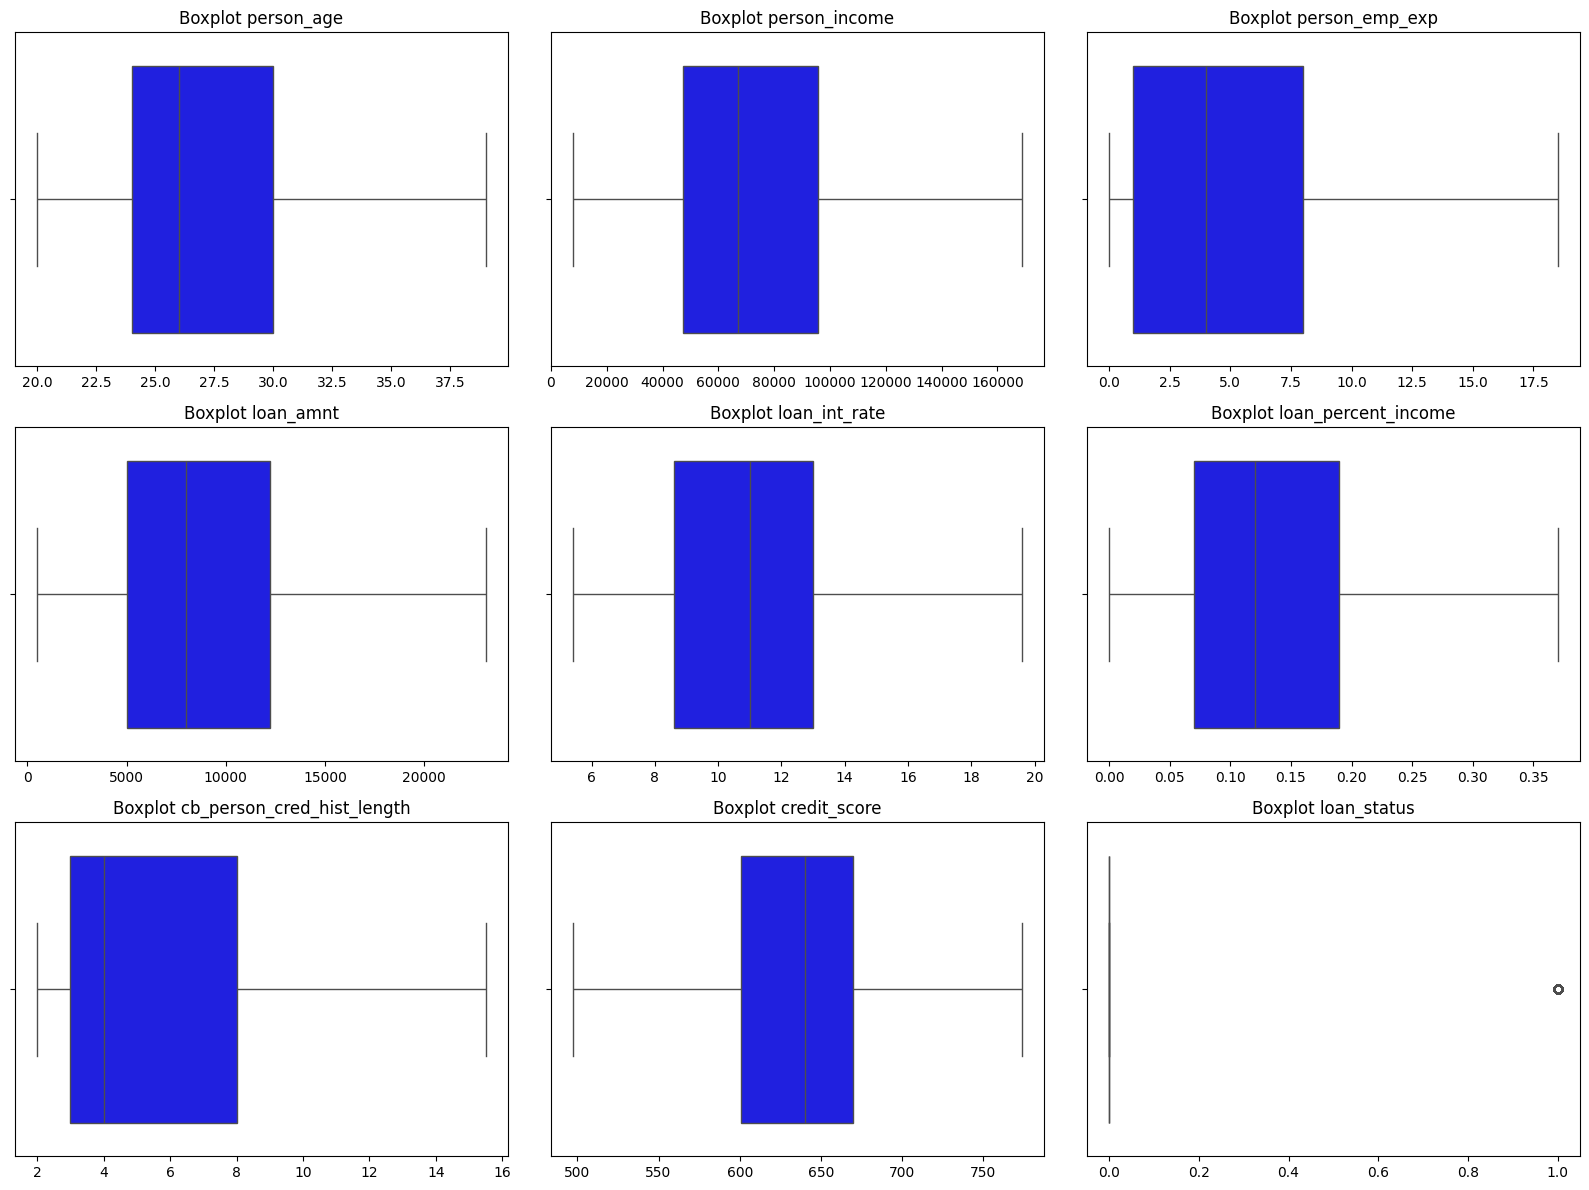

In [15]:
# mengecek outlier

num_features = df_pre.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))

for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 3, i) # Menyesuaikan grid (3 baris x 3 kolom = 9 fitur)
    
    sns.boxplot(x=df_pre[column], color='blue') 
    
    plt.title(f'Boxplot {column}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [16]:
# Binning 

bins_usia = [0, 25, 35, 50, 100]
labels_age = ['Remaja','Dewasa','Paruh Baya','Lansia']
df_pre['age_group'] = pd.cut(df_pre['person_age'], bins = bins_usia, labels=labels_age)


bins_credit = [0, 579, 669, 739, 850]
labels_credit = ['Poor', 'Fair', 'Good', 'Excellent']
df_pre['credit_score_group'] = pd.cut(df_pre['credit_score'], bins=bins_credit, labels=labels_credit)


bins_exp = [-1, 2, 5, 10, 50] 
labels_exp = ['Fresher', 'Mid-Level', 'Senior', 'Veteran']
df_pre['emp_exp_group'] = pd.cut(df_pre['person_emp_exp'], bins=bins_exp, labels=labels_exp)

print(df_pre[['credit_score', 'credit_score_group', 'person_emp_exp', 'emp_exp_group']].head(10))

   credit_score credit_score_group  person_emp_exp emp_exp_group
0         561.0               Poor             0.0       Fresher
1         504.0               Poor             0.0       Fresher
2         635.0               Fair             3.0     Mid-Level
3         675.0               Good             0.0       Fresher
4         586.0               Fair             1.0       Fresher
5         532.0               Poor             0.0       Fresher
6         701.0               Good             1.0       Fresher
7         585.0               Fair             5.0     Mid-Level
8         544.0               Poor             3.0     Mid-Level
9         640.0               Fair             0.0       Fresher


In [17]:
df_pre.sample(15)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,age_group,credit_score_group,emp_exp_group
5667,22.0,male,Bachelor,56262.0,0.0,MORTGAGE,6400.0,DEBTCONSOLIDATION,8.59,0.11,3.0,512.0,Yes,0,Remaja,Poor,Fresher
21812,28.0,male,Master,61079.0,5.0,MORTGAGE,3000.0,PERSONAL,11.01,0.05,10.0,661.0,Yes,0,Dewasa,Fair,Mid-Level
1014,23.0,male,Associate,76732.0,2.0,RENT,18000.0,EDUCATION,10.99,0.23,3.0,618.0,Yes,0,Remaja,Fair,Fresher
18910,32.0,male,Associate,56042.0,11.0,RENT,1800.0,MEDICAL,11.58,0.03,9.0,657.0,Yes,0,Dewasa,Fair,Veteran
14264,24.0,female,Bachelor,124427.0,0.0,MORTGAGE,5000.0,VENTURE,14.22,0.04,4.0,662.0,No,0,Remaja,Fair,Fresher
1421,21.0,male,Bachelor,32384.0,0.0,OWN,4000.0,VENTURE,7.51,0.12,4.0,632.0,Yes,0,Remaja,Fair,Fresher
1195,26.0,female,Bachelor,57881.0,3.0,RENT,16500.0,MEDICAL,11.01,0.29,4.0,515.0,No,1,Dewasa,Poor,Mid-Level
2596,25.0,male,High School,45098.0,3.0,RENT,3000.0,MEDICAL,11.71,0.07,2.0,642.0,No,0,Remaja,Fair,Mid-Level
20406,29.0,female,Associate,49256.0,8.0,MORTGAGE,4000.0,DEBTCONSOLIDATION,14.35,0.08,6.0,620.0,No,0,Dewasa,Fair,Senior
20259,30.0,female,Master,48982.0,9.0,MORTGAGE,10000.0,PERSONAL,10.75,0.20,8.0,579.0,Yes,0,Dewasa,Poor,Senior


In [18]:

# Encoding 
df_encode = df_pre.copy()


df_encode['person_gender'] = LabelEncoder().fit_transform(df_encode['person_gender'])

df_encode['previous_loan_defaults_on_file'] = df_encode['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})


education_order = [
    'High School', 
    'Associate', 
    'Bachelor', 
    'Master', 
    'Doctorate'
]

age_order = [
    'Remaja',
    'Dewasa',
    'Paruh Baya',
    'Lansia'
]

credit_order = [
    'Poor',
    'Fair',
    'Good',
    'Excellent' 
]

exp_order = [
    'Fresher',
    'Mid-Level',
    'Senior',
    'Veteran'
]

oe = OrdinalEncoder(categories=[education_order, age_order, credit_order, exp_order])
ordinalcolumn = ['person_education', 'age_group', 'credit_score_group', 'emp_exp_group']

df_encode[ordinalcolumn] = oe.fit_transform(df_encode[ordinalcolumn])


df_encode = pd.get_dummies(
    df_encode, columns=['person_home_ownership', 'loan_intent'], 
    drop_first=True,
    dtype=int
)


kolom_dibuang = ['person_age', 'credit_score', 'person_emp_exp']
df_encode = df_encode.drop(columns=kolom_dibuang)

print(f"Shape setelah encoding : {df_encode.shape}")
print(f"\nKolom hasil encoding:")
for col in df_encode.columns:
    print(f"  - {col}")

Shape setelah encoding : (45000, 20)

Kolom hasil encoding:
  - person_gender
  - person_education
  - person_income
  - loan_amnt
  - loan_int_rate
  - loan_percent_income
  - cb_person_cred_hist_length
  - previous_loan_defaults_on_file
  - loan_status
  - age_group
  - credit_score_group
  - emp_exp_group
  - person_home_ownership_OTHER
  - person_home_ownership_OWN
  - person_home_ownership_RENT
  - loan_intent_EDUCATION
  - loan_intent_HOMEIMPROVEMENT
  - loan_intent_MEDICAL
  - loan_intent_PERSONAL
  - loan_intent_VENTURE


In [19]:
df_encode.head()

,person_gender,person_education,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,previous_loan_defaults_on_file,loan_status,age_group,credit_score_group,emp_exp_group,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,0,3.0,71948.0,23093.125,16.02,0.37,3.0,0,1,0.0,0.0,0.0,0,0,1,0,0,0,1,0
1,0,0.0,12282.0,1000.000,11.14,0.08,2.0,1,0,0.0,0.0,0.0,0,1,0,1,0,0,0,0
2,0,0.0,12438.0,5500.000,12.87,0.37,3.0,0,1,0.0,1.0,1.0,0,0,0,0,0,1,0,0
3,0,2.0,79753.0,23093.125,15.23,0.37,2.0,0,1,0.0,2.0,0.0,0,0,1,0,0,1,0,0
4,1,3.0,66135.0,23093.125,14.27,0.37,4.0,0,1,0.0,1.0,0.0,0,0,1,0,0,1,0,0


In [20]:
# menyimpan dataset

df_encode.to_csv(os.path.join(PATH, 'loan_data_pre.csv'), index=False)
print("Data Preprocessing berhasil disimpan ke 'loan_data_pre.csv'")

Data Preprocessing berhasil disimpan ke 'loan_data_pre.csv'
